In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import seaborn as sns

In [4]:
heart_df = pd.read_csv("heart.csv")
X = heart_df.drop(columns=["target"])
Y = heart_df["target"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
knn_classifier = KNeighborsClassifier(n_neighbors=3)
knn_classifier.fit(X_train_scaled,Y_train)

Y_pred = knn_classifier.predict(X_test_scaled)
print(classification_report(Y_test,Y_pred))
print("\n",accuracy_score(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.79      0.93      0.86        29
           1       0.93      0.78      0.85        32

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61


 0.8524590163934426


In [6]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_scaled,Y_train)

Y_pred = knn_classifier.predict(X_test_scaled)
print(classification_report(Y_test,Y_pred))
print("\n",accuracy_score(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


 0.9016393442622951


In [7]:
knn_classifier = KNeighborsClassifier(n_neighbors=7)
knn_classifier.fit(X_train_scaled,Y_train)

Y_pred = knn_classifier.predict(X_test_scaled)
print(classification_report(Y_test,Y_pred))
print("\n",accuracy_score(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61


 0.9180327868852459


In [8]:
knn_classifier = KNeighborsClassifier(n_neighbors=9)
knn_classifier.fit(X_train_scaled,Y_train)

Y_pred = knn_classifier.predict(X_test_scaled)
print(classification_report(Y_test,Y_pred))
print("\n",accuracy_score(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


 0.9016393442622951


In [9]:
heart_df.columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

<Axes: xlabel='age', ylabel='chol'>

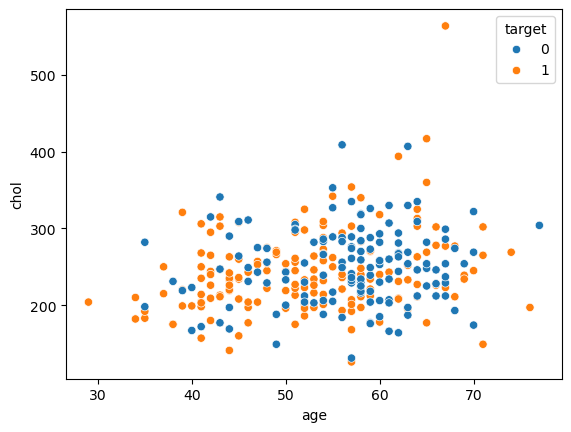

In [10]:
sns.scatterplot(heart_df,x="age",y="chol",hue="target")

# Validation using GridSearchCV

In [11]:
from sklearn.model_selection import GridSearchCV
classifier = knn_classifier
param_grid = {
    "n_neighbors": [3,5,7,9]
}

classifierCV = GridSearchCV(estimator=classifier,
    param_grid=param_grid,
    cv=5,
    scoring="recall"
)

classifierCV.fit(X_train_scaled,Y_train)
Y_pred = classifierCV.predict(X_test_scaled)
print(classification_report(Y_test,Y_pred))

res = pd.DataFrame(classifierCV.cv_results_)
res[["param_n_neighbors","mean_test_score"]]

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



,param_n_neighbors,mean_test_score
0,3,0.864387
1,5,0.857550
2,7,0.871795
3,9,0.856980


In [12]:
classifierCV.best_params_

{'n_neighbors': 7}

# Pipeline

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV



pipeline = Pipeline(    
    [(
        'scaler',
        StandardScaler()
    ),
    (
        'knn',
        KNeighborsClassifier()
    )]
)
param_grid = {
    "knn__n_neighbors": [3,5,7,9]
}

classifierCV = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="recall"
)
classifierCV.fit(X_train,Y_train)
Y_pred = classifierCV.predict(X_test)
print(classification_report(Y_test,Y_pred))
print(classifierCV.best_params_)

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61

{'knn__n_neighbors': 7}
